<a href="https://colab.research.google.com/github/frankchieng1982/2048-in-react/blob/master/S33_vacuum_sensing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamic Bayesian Networks

<a href="https://colab.research.google.com/github/gtbook/robotics/blob/main/S33_vacuum_sensing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -U -q gtbook


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have

In [2]:
import gtsam

import gtbook
import gtbook.display
from gtbook import vacuum
from gtbook.discrete import Variables
VARIABLES = Variables()
def pretty(obj):
    return gtbook.display.pretty(obj, VARIABLES)
def show(obj, **kwargs):
    return gtbook.display.show(obj, VARIABLES, **kwargs)


In [3]:
# From section 3.2:
wxyz = gtsam.DiscreteBayesNet()
W1 = VARIABLES.binary("W")
X1 = VARIABLES.binary("X")
Y1 = VARIABLES.binary("Y")
Z1 = VARIABLES.binary("Z")
wxyz.add(W1, [X1, Z1], "1/1 1/1 1/1 1/1")
wxyz.add(X1, [Y1, Z1], "1/1 1/1 1/1 1/1")
wxyz.add(Y1, [Z1], "1/1 1/1")
wxyz.add(Z1, "1/1")

N = 5
X = VARIABLES.discrete_series("X", range(1, N+1), vacuum.rooms)
A = VARIABLES.discrete_series("A", range(1, N), vacuum.action_space)


```{index} sensing; dynamic Bayes nets
```

> Dynamic Bayes nets replicate a Bayes net fragment over time.

<img src="https://github.com/gtbook/robotics/blob/main/Figures3/S33-iRobot_vacuuming_robot-01.jpg?raw=1" alt="Splash image with balancing steampunk robot sporting big eyes" width="40%" align=center style="vertical-align:middle;margin:10px 0px">

```{index} pair: dynamic Bayes net; DBN
```

The concepts we discussed in the previous section can be generalized to include sensing, and here we introduce a much more general framework that we will use over and over in this book.
In particular, the controlled Markov chain over successive states $X_t$ is an instance of a **dynamic Bayes net** or **DBN**:
a Bayes net in which *Bayes net slices* are replicated through time to model the evolution of states over time.
Below, we add observations/measurements into the mix and show how we can simulate the complete system using a more general technique called *ancestral sampling*.

```{index} ancestral sampling
```

While most of the sensor modeling here is largely a reprise of Section 2.3, the concept of a dynamic Bayes net is an incredible modeling tool that we will use repeatedly throughout this book.
The notion of ancestral sampling is also very powerful and underlies simulation for much more general robot systems, not just the discrete-state model we consider here.

## A Sensor Model

> A simple light sensor.

This chapter is primarily focused on action, and hence the sensing we will consider is fairly straightforward.
Let us conceive of a simple light sensor that we can use as a clue about which room the robot is in.
Specifically, let us assume for illustration's sake that the living room and kitchen are on the south side, and hence have a lot of light on a typical day.
The office and the dining room are on the north side, and the light sensor will typically respond with medium light levels.
The hallway, on the other hand, is very dark as it has few windows.
We can capture these semantics with a conditional probability distribution $P(Z_t|X_t)$, where $X_t$ is the state at time $t$ as before, and $Z_t \in \{\text{dark}, \text{medium}, \text{light}\}$ is the measured light level.

The small code snippet in Figure [1](#fig:vacuum-sensor-spec) is one way to create a reasonable sensor model.

In [4]:
#| caption: Creating a sensor model $P(Z_t|X_t)$ using a string-based specification.
#| label: fig:vacuum-sensor-spec
# vacuum.light_levels = ["dark", "medium", "light"]
Z = VARIABLES.discrete_series("Z", range(1, N+1), vacuum.light_levels) # define variables
# vacuum.sensor_spec = "1/1/8 1/1/8 2/7/1 8/1/1 1/8/1"
pretty(gtsam.DiscreteConditional(Z[1], [X[1]], vacuum.sensor_spec)) # CPT on Z1 at time t=1


X1,dark,medium,light
Living Room,0.1,0.1,0.8
Kitchen,0.1,0.1,0.8
Office,0.2,0.7,0.1
Hallway,0.8,0.1,0.1
Dining Room,0.1,0.8,0.1


There are several things to notice.
- This is again a *discrete* sensor; we have encountered these before in Chapter 2.
- It is an imperfect sensor, and hence each room has a most likely outcome, but all outcomes are possible in all rooms.
- The CPT (conditional probability table) above also captures modeling issues, such as varying light levels throughout the day.

### Exercise
Change the values in the CPT and see how those changes affect the rest of the code in this section. Specifically, try some CPT versions where some outcomes have zero probability.

DYNAMIC BAYESIAN NETWORKS WITH SENSING

Locations: ['L', 'K', 'O', 'H', 'D']
Light levels: ['dark', 'medium', 'light']
Actions: ['R', 'L', 'S', 'U', 'Dn']
Using Python's random module (seed=42)

1. SENSOR MODEL P(Z_t | X_t)

Sensor model (rows: location, columns: light level):
         dark  medium  light
L            0.10    0.10     0.80
K            0.10    0.10     0.80
O            0.20    0.70     0.10
H            0.80    0.10     0.10
D            0.10    0.80     0.10


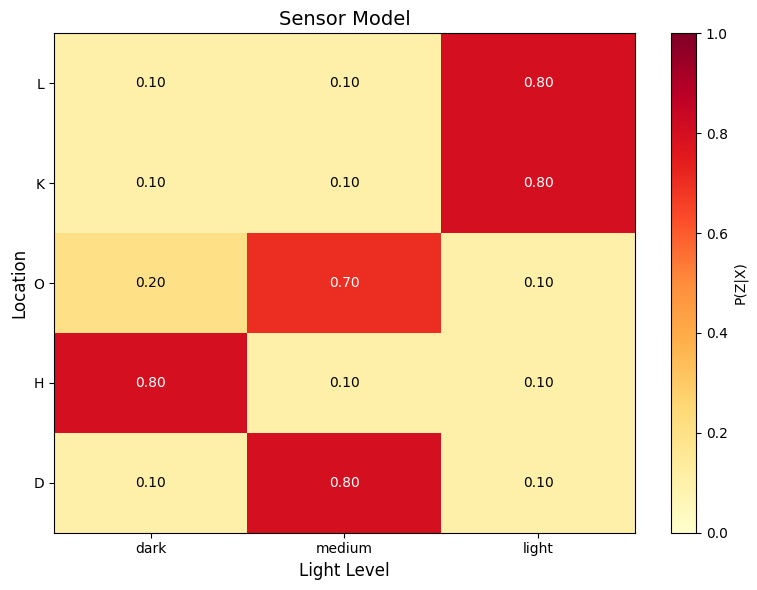


2. ANCESTRAL SAMPLING

Initial location: O
Action sequence: ['R', 'R', 'L', 'R']

Rollout results:
  Locations: ['O', 'H', 'D', 'H', 'D']
  Observations: ['dark', 'medium', 'dark', 'dark']
  Actions: ['R', 'R', 'L', 'R']


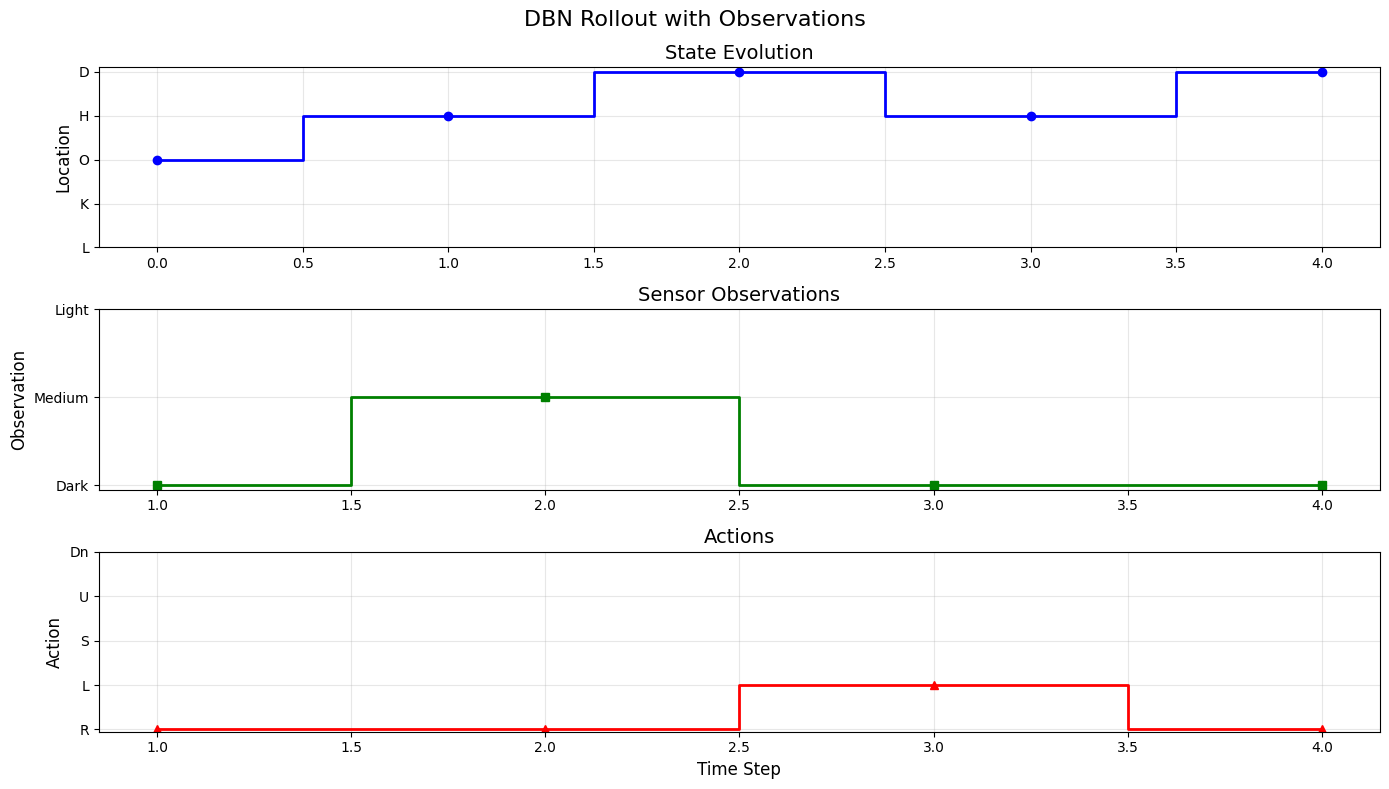


3. MULTIPLE ROLLOUTS

Performed 20 rollouts

First 5 rollouts:
  Rollout 1: locations=['O', 'H', 'D', 'H', 'D'], obs=['dark', 'medium', 'dark', 'medium']
  Rollout 2: locations=['O', 'H', 'D', 'D', 'H'], obs=['dark', 'dark', 'medium', 'dark']
  Rollout 3: locations=['O', 'H', 'H', 'D', 'D'], obs=['dark', 'dark', 'medium', 'medium']
  Rollout 4: locations=['O', 'H', 'D', 'D', 'D'], obs=['light', 'medium', 'medium', 'medium']
  Rollout 5: locations=['O', 'H', 'D', 'H', 'H'], obs=['dark', 'medium', 'dark', 'dark']

4. EMPIRICAL DISTRIBUTIONS

Empirical location distribution at final step:
  P(L) = 0.000
  P(K) = 0.050
  P(O) = 0.050
  P(H) = 0.350
  P(D) = 0.550

Empirical observation distribution at final step:
  P(dark) = 0.350
  P(medium) = 0.500
  P(light) = 0.150

5. BELIEF FILTERING

Using rollout example:
  Actions: ['R', 'R', 'L', 'R']
  Observations: ['dark', 'medium', 'dark', 'medium']

Belief evolution:
  t=0 (initial): [0.2 0.2 0.2 0.2 0.2]
  t=1 (after action R, obs dark): [

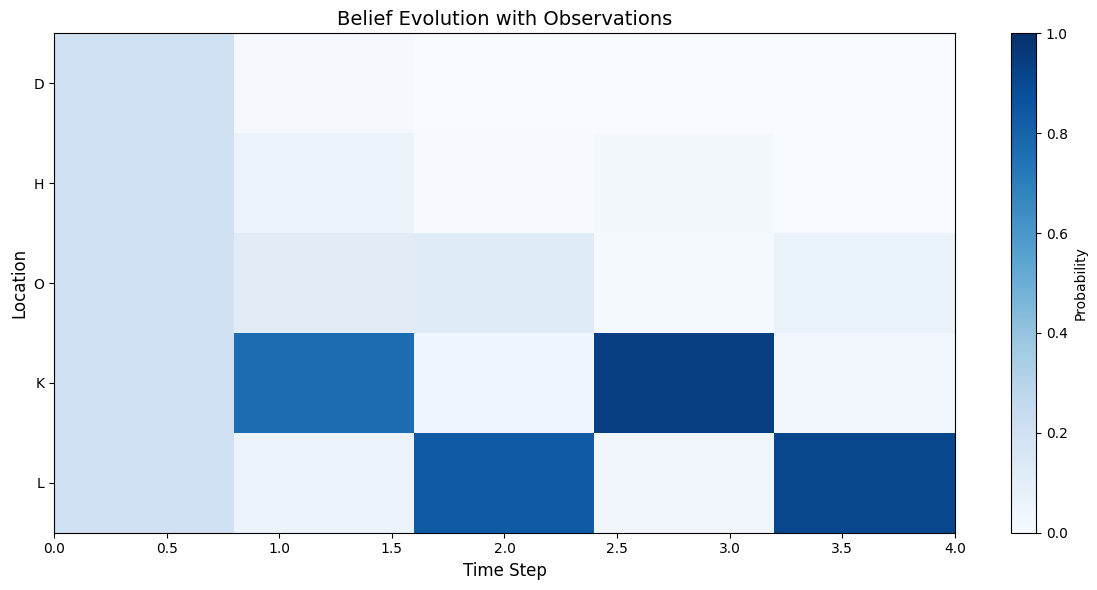


6. COMPARING DIFFERENT SENSOR MODELS


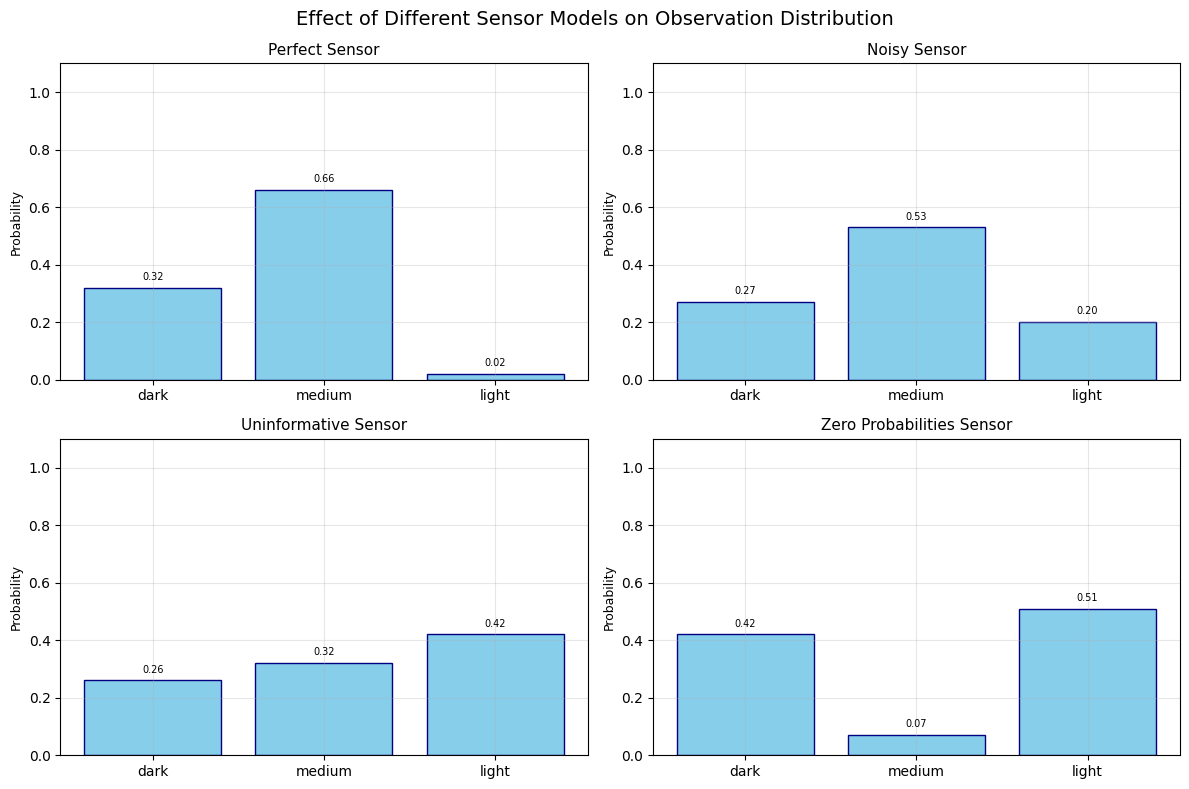


7. EFFECT OF ZERO PROBABILITIES

When some outcomes have zero probability:
  - The robot can be certain about some states
  - Belief updates can eliminate impossible states
  - This can lead to faster convergence

Belief evolution with perfect sensor:
  t=0 (initial): [0.2 0.2 0.2 0.2 0.2]
  t=1 (after action R, obs dark): [0. 0. 0. 1. 0.]
  t=2 (after action R, obs medium): [0.    0.    0.059 0.    0.941]
  t=3 (after action L, obs dark): [0. 0. 0. 1. 0.]
  t=4 (after action R, obs medium): [0.    0.    0.059 0.    0.941]


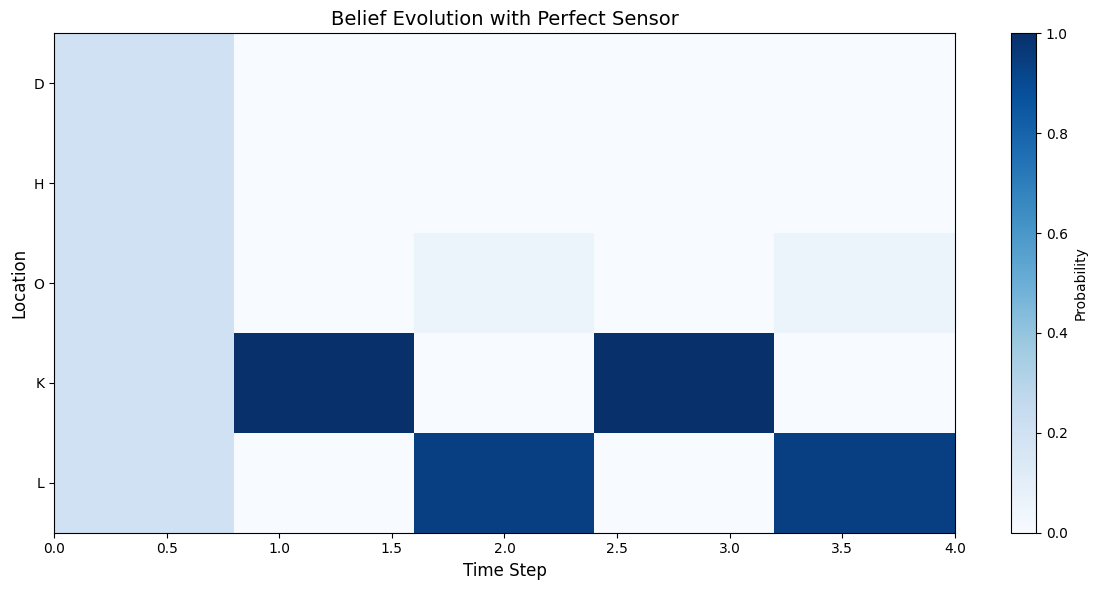


8. FACTORED DBN WITH BATTERY

Factored rollout with battery:
  Locations: ['O', 'H', 'D', 'H', 'D']
  Battery: ['full', 'half', 'empty', 'empty', 'empty']
  Observations: ['dark', 'medium', 'dark', 'medium']


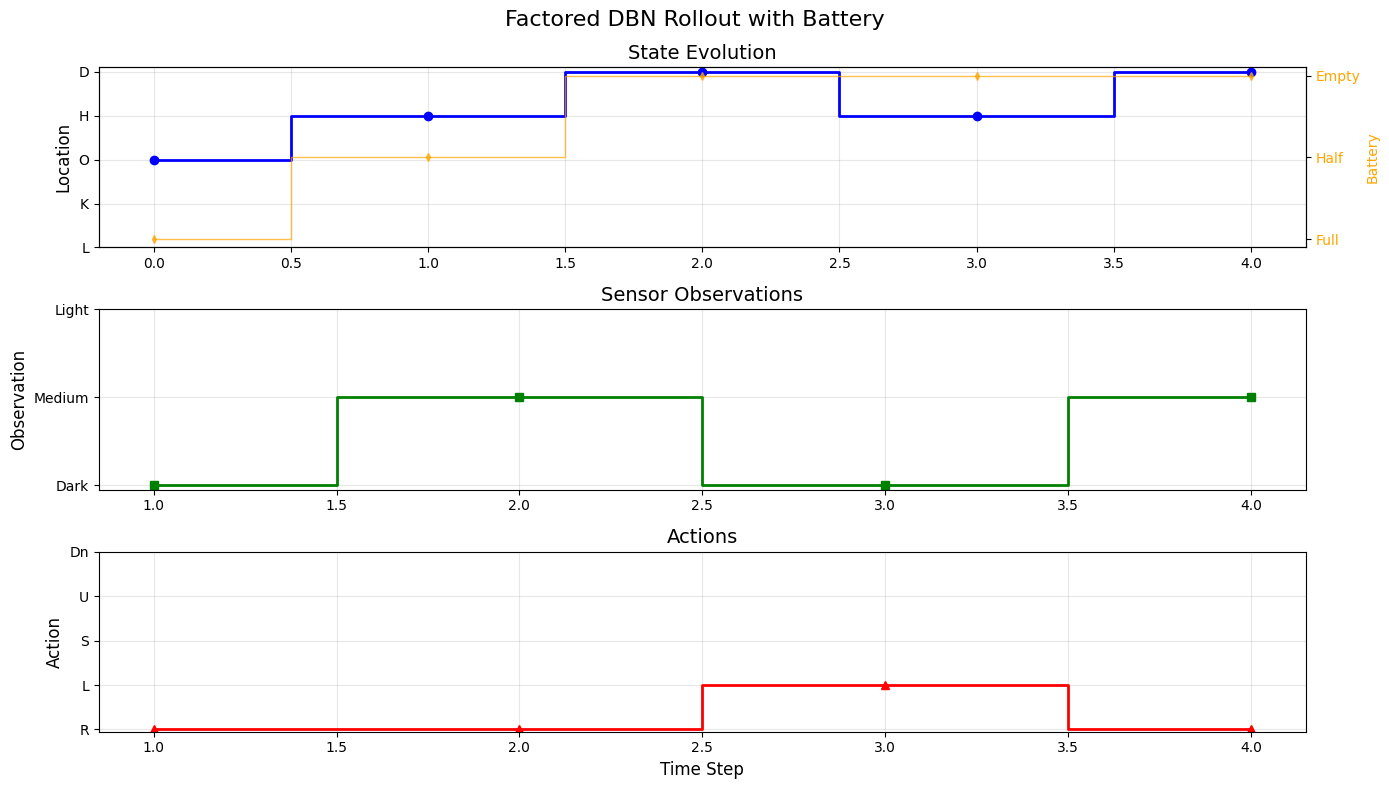


9. EXERCISE: MODIFYING THE SENSOR MODEL

Try modifying the sensor model CPT:
Example 1: Make Hallway perfectly dark (P(dark)=1.0):

Observation distribution with modified sensor:
  P(dark) = 0.460
  P(medium) = 0.500
  P(light) = 0.040

Example 2: Make Living Room and Kitchen indistinguishable:

Observation distribution with indistinguishable L and K:
  P(dark) = 0.320
  P(medium) = 0.640
  P(light) = 0.040

SUMMARY

Key concepts demonstrated:
1. Dynamic Bayesian Networks extend Bayes nets over time
2. Sensor models P(Z_t | X_t) capture measurement uncertainty
3. Ancestral sampling generates complete trajectories
4. Belief filtering combines prediction and update steps
5. Sensor models with zero probabilities can eliminate states
6. Factored representations can include multiple state variables

Exercise: Try modifying the sensor model to see how it affects:
  - Belief convergence rate
  - Observation distributions
  - Ability to localize the robot

Suggested modifications:
  1. Make H

In [6]:
import sys
import warnings
warnings.filterwarnings('ignore')

# Try to import numpy for array operations only
try:
    import numpy as np
except ValueError as e:
    if "numpy.dtype size changed" in str(e):
        print("Detected numpy dtype compatibility issue. Using workaround...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "numpy", "--force-reinstall", "--no-cache-dir"])
        import numpy as np
    else:
        raise

import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional, Set, Any
from collections import defaultdict, Counter
import random
from itertools import product
import networkx as nx

class DynamicBayesianNetwork:
    """
    Implementation of a Dynamic Bayesian Network (DBN) with:
    - States: X_t (location)
    - Actions: A_t (control inputs)
    - Observations: Z_t (sensor measurements)
    - Battery: B_t (optional factored state)
    """

    def __init__(self, seed: int = 42):
        # State space (location)
        self.locations = ['L', 'K', 'O', 'H', 'D']
        self.location_to_idx = {s: i for i, s in enumerate(self.locations)}
        self.n_locations = len(self.locations)

        # Observation space (light levels)
        self.light_levels = ['dark', 'medium', 'light']
        self.light_to_idx = {s: i for i, s in enumerate(self.light_levels)}
        self.n_light_levels = len(self.light_levels)

        # Battery states (for factored representation)
        self.battery_states = ['full', 'half', 'empty']
        self.battery_to_idx = {s: i for i, s in enumerate(self.battery_states)}
        self.n_battery = len(self.battery_states)

        # Actions
        self.actions = ['R', 'L', 'S', 'U', 'Dn']
        self.action_to_idx = {a: i for i, a in enumerate(self.actions)}
        self.n_actions = len(self.actions)

        # Create transition models
        self.location_transition = self._create_location_transition()
        self.battery_transition = self._create_battery_transition()
        self.sensor_model = self._create_sensor_model()

        # Set random seed (using Python's random module)
        self.seed = seed
        random.seed(seed)

    def _create_location_transition(self) -> Dict[str, np.ndarray]:
        """Create location transition matrices P(X_{t+1} | X_t, A_t)."""
        p_correct = 0.8
        p_stay = 0.15
        p_wrong = 0.05

        def create_right_matrix():
            M = np.zeros((5, 5), dtype=np.float64)
            for i in range(5):
                if i < 4:
                    M[i, i+1] = p_correct
                    M[i, i] = p_stay
                    if i > 0:
                        M[i, i-1] = p_wrong
                    else:
                        M[i, i+1] += p_wrong
                else:
                    M[i, i] = p_stay + p_wrong
                    M[i, i-1] = p_correct
            return M

        M_right = create_right_matrix()
        matrices = {
            'R': M_right,
            'L': M_right.T,
            'S': np.eye(5, dtype=np.float64),
            'U': M_right.copy(),
            'Dn': M_right.T.copy(),
        }

        # Normalize
        for key in matrices:
            row_sums = matrices[key].sum(axis=1, keepdims=True)
            row_sums = np.where(row_sums == 0, 1, row_sums)
            matrices[key] = matrices[key] / row_sums

        return matrices

    def _create_battery_transition(self) -> np.ndarray:
        """Create battery transition matrix P(B_{t+1} | B_t)."""
        M = np.zeros((3, 3), dtype=np.float64)
        M[0, 1] = 0.9  # full -> half
        M[0, 2] = 0.1  # full -> empty
        M[1, 2] = 0.9  # half -> empty
        M[1, 0] = 0.1  # half -> full (recharge)
        M[2, 2] = 1.0  # empty -> empty
        return M

    def _create_sensor_model(self) -> np.ndarray:
        """
        Create sensor model P(Z_t | X_t).
        Rows: locations, Columns: light levels
        """
        # Default sensor model from the textbook
        sensor = np.zeros((5, 3), dtype=np.float64)

        # Living Room: mostly light
        sensor[0] = [0.1, 0.1, 0.8]
        # Kitchen: mostly light
        sensor[1] = [0.1, 0.1, 0.8]
        # Office: mostly medium
        sensor[2] = [0.2, 0.7, 0.1]
        # Hallway: mostly dark
        sensor[3] = [0.8, 0.1, 0.1]
        # Dining Room: mostly medium
        sensor[4] = [0.1, 0.8, 0.1]

        # Normalize rows
        row_sums = sensor.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1, row_sums)
        sensor = sensor / row_sums

        return sensor

    def set_sensor_model(self, sensor_model: np.ndarray):
        """Set a custom sensor model."""
        if sensor_model.shape != (self.n_locations, self.n_light_levels):
            raise ValueError(f"Expected shape ({self.n_locations}, {self.n_light_levels})")

        # Normalize rows
        row_sums = sensor_model.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1, row_sums)
        self.sensor_model = sensor_model / row_sums

    def _sample_from_probs(self, probs: np.ndarray) -> int:
        """Sample from a probability distribution using Python's random."""
        r = random.random()
        cumulative = 0.0
        for i, prob in enumerate(probs):
            cumulative += prob
            if r < cumulative:
                return i
        return len(probs) - 1

    def get_transition_prob(self, current_loc: str, action: str, next_loc: str) -> float:
        """Get P(X_{t+1} | X_t, A_t)."""
        i = self.location_to_idx[current_loc]
        j = self.location_to_idx[next_loc]
        return float(self.location_transition[action][i, j])

    def get_sensor_prob(self, location: str, light_level: str) -> float:
        """Get P(Z_t | X_t)."""
        i = self.location_to_idx[location]
        j = self.light_to_idx[light_level]
        return float(self.sensor_model[i, j])

    def sample_location(self, current_loc: str, action: str) -> str:
        """Sample next location from P(X_{t+1} | X_t, A_t)."""
        i = self.location_to_idx[current_loc]
        probs = self.location_transition[action][i]
        idx = self._sample_from_probs(probs)
        return self.locations[idx]

    def sample_battery(self, current_bat: str) -> str:
        """Sample next battery from P(B_{t+1} | B_t)."""
        i = self.battery_to_idx[current_bat]
        probs = self.battery_transition[i]
        idx = self._sample_from_probs(probs)
        return self.battery_states[idx]

    def sample_observation(self, location: str) -> str:
        """Sample observation from P(Z_t | X_t)."""
        i = self.location_to_idx[location]
        probs = self.sensor_model[i]
        idx = self._sample_from_probs(probs)
        return self.light_levels[idx]

    def ancestral_sample(self, initial_location: str, initial_battery: str = 'full',
                        action_sequence: List[str] = None, n_steps: int = None,
                        include_battery: bool = False) -> Dict:
        """
        Perform ancestral sampling from the DBN.

        Args:
            initial_location: Starting location
            initial_battery: Starting battery state
            action_sequence: Sequence of actions
            n_steps: Number of steps to simulate
            include_battery: Whether to include battery in simulation

        Returns:
            Dictionary with states, actions, observations, and battery
        """
        if n_steps is None:
            n_steps = len(action_sequence) if action_sequence else 5
        if action_sequence is None:
            action_sequence = ['S'] * n_steps
        elif len(action_sequence) < n_steps:
            action_sequence = list(action_sequence) + ['S'] * (n_steps - len(action_sequence))

        # Initialize
        locations = [initial_location]
        battery = [initial_battery]
        observations = []
        actions = []

        for k, action in enumerate(action_sequence[:n_steps]):
            # Sample next location (depends on action)
            next_loc = self.sample_location(locations[-1], action)

            # Sample next battery (independent of action and location)
            next_bat = self.sample_battery(battery[-1]) if include_battery else battery[-1]

            # Sample observation (depends on current location)
            obs = self.sample_observation(next_loc)

            locations.append(next_loc)
            battery.append(next_bat)
            observations.append(obs)
            actions.append(action)

        return {
            'locations': locations,
            'battery': battery if include_battery else None,
            'observations': observations,
            'actions': actions
        }

    def multiple_rollouts(self, initial_location: str, initial_battery: str = 'full',
                         action_sequence: List[str] = None, n_steps: int = None,
                         num_rollouts: int = 10, include_battery: bool = False) -> List[Dict]:
        """Perform multiple ancestral sampling rollouts."""
        rollouts = []
        for _ in range(num_rollouts):
            rollout = self.ancestral_sample(initial_location, initial_battery,
                                           action_sequence, n_steps, include_battery)
            rollouts.append(rollout)
        return rollouts

    def compute_empirical_distribution(self, rollouts: List[Dict],
                                      time_step: int = -1,
                                      variable: str = 'location') -> Dict[str, float]:
        """
        Compute empirical distribution over a variable at a given time step.

        Args:
            rollouts: List of rollout dictionaries
            time_step: Time step to analyze (-1 for final)
            variable: 'location', 'battery', or 'observation'
        """
        if time_step == -1:
            time_step = len(rollouts[0]['locations']) - 1

        if variable == 'location':
            values = [r['locations'][time_step] for r in rollouts]
            all_values = self.locations
        elif variable == 'battery':
            values = [r['battery'][time_step] for r in rollouts]
            all_values = self.battery_states
        elif variable == 'observation':
            # Observations are at time t (when measuring X_t)
            # For time_step, we look at observation at time_step - 1
            obs_time = time_step - 1
            if obs_time < 0:
                return {v: 0 for v in self.light_levels}
            values = [r['observations'][obs_time] for r in rollouts]
            all_values = self.light_levels
        else:
            raise ValueError(f"Unknown variable: {variable}")

        counter = Counter(values)
        total = len(rollouts)
        return {v: counter.get(v, 0) / total for v in all_values}

    def compute_belief_update(self, prior: np.ndarray, action: str,
                             observation: str) -> np.ndarray:
        """
        Perform a single step of belief update:
        b_{t+1} = η * P(Z_t | X_t) * Σ_x P(X_t | X_{t-1}, A_t) * b_{t-1}
        """
        # Prediction step
        pred = prior @ self.location_transition[action]

        # Update step with observation
        obs_idx = self.light_to_idx[observation]
        likelihood = self.sensor_model[:, obs_idx]

        posterior = pred * likelihood
        posterior_sum = posterior.sum()
        if posterior_sum > 0:
            posterior = posterior / posterior_sum
        else:
            # If all probabilities are zero, keep uniform
            posterior = np.ones_like(posterior) / len(posterior)

        return posterior

    def compute_filtering_distribution(self, initial_belief: np.ndarray,
                                      action_sequence: List[str],
                                      observation_sequence: List[str]) -> List[np.ndarray]:
        """Compute filtering distribution over time."""
        beliefs = [initial_belief.copy()]

        for t, (action, obs) in enumerate(zip(action_sequence, observation_sequence)):
            next_belief = self.compute_belief_update(beliefs[-1], action, obs)
            beliefs.append(next_belief)

        return beliefs

class DBNVisualizer:
    """Visualization utilities for Dynamic Bayesian Networks."""

    @staticmethod
    def plot_dbn_rollout(rollout: Dict, title: str = "DBN Rollout",
                        figsize: Tuple[int, int] = (14, 8)):
        """Plot a single DBN rollout showing states, actions, and observations."""
        n_steps = len(rollout['locations'])

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=figsize)

        # Location evolution
        loc_indices = [['L', 'K', 'O', 'H', 'D'].index(s) for s in rollout['locations']]
        ax1.step(range(n_steps), loc_indices, where='mid',
                linewidth=2, color='blue', marker='o', markersize=6)
        ax1.set_yticks(range(5))
        ax1.set_yticklabels(['L', 'K', 'O', 'H', 'D'])
        ax1.set_ylabel('Location', fontsize=12)
        ax1.set_title('State Evolution', fontsize=14)
        ax1.grid(True, alpha=0.3)

        # Observations
        obs_indices = [['dark', 'medium', 'light'].index(s) for s in rollout['observations']]
        ax2.step(range(1, n_steps), obs_indices, where='mid',
                linewidth=2, color='green', marker='s', markersize=6)
        ax2.set_yticks(range(3))
        ax2.set_yticklabels(['Dark', 'Medium', 'Light'])
        ax2.set_ylabel('Observation', fontsize=12)
        ax2.set_title('Sensor Observations', fontsize=14)
        ax2.grid(True, alpha=0.3)

        # Actions
        if rollout.get('actions'):
            action_indices = [['R', 'L', 'S', 'U', 'Dn'].index(a) for a in rollout['actions']]
            ax3.step(range(1, n_steps), action_indices, where='mid',
                    linewidth=2, color='red', marker='^', markersize=6)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(['R', 'L', 'S', 'U', 'Dn'])
            ax3.set_ylabel('Action', fontsize=12)
            ax3.set_xlabel('Time Step', fontsize=12)
            ax3.set_title('Actions', fontsize=14)
            ax3.grid(True, alpha=0.3)

        # Add battery if present
        if rollout.get('battery'):
            bat_ax = ax1.twinx()
            bat_indices = [['full', 'half', 'empty'].index(s) for s in rollout['battery']]
            bat_ax.step(range(n_steps), bat_indices, where='mid',
                       linewidth=1, color='orange', marker='d', markersize=4, alpha=0.7)
            bat_ax.set_yticks(range(3))
            bat_ax.set_yticklabels(['Full', 'Half', 'Empty'])
            bat_ax.set_ylabel('Battery', fontsize=10, color='orange')
            bat_ax.tick_params(axis='y', labelcolor='orange')

        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_belief_evolution(beliefs: List[np.ndarray], locations: List[str],
                             title: str = "Belief Evolution"):
        """Plot the evolution of beliefs over time."""
        n_steps = len(beliefs)
        belief_matrix = np.array(beliefs).T

        fig, ax = plt.subplots(figsize=(12, 6))
        im = ax.imshow(belief_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1,
                      extent=[0, n_steps-1, 0, len(locations)])

        ax.set_yticks(np.arange(len(locations)) + 0.5)
        ax.set_yticklabels(locations)
        ax.set_xlabel('Time Step', fontsize=12)
        ax.set_ylabel('Location', fontsize=12)
        ax.set_title(title, fontsize=14)

        plt.colorbar(im, label='Probability')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_sensor_model(sensor_model: np.ndarray, locations: List[str],
                         light_levels: List[str], title: str = "Sensor Model"):
        """Visualize the sensor model."""
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(sensor_model, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

        ax.set_xticks(range(len(light_levels)))
        ax.set_yticks(range(len(locations)))
        ax.set_xticklabels(light_levels)
        ax.set_yticklabels(locations)
        ax.set_xlabel('Light Level', fontsize=12)
        ax.set_ylabel('Location', fontsize=12)
        ax.set_title(title, fontsize=14)

        # Add text annotations
        for i in range(len(locations)):
            for j in range(len(light_levels)):
                text = ax.text(j, i, f'{sensor_model[i, j]:.2f}',
                              ha="center", va="center",
                              color="black" if sensor_model[i, j] < 0.5 else "white")

        plt.colorbar(im, label='P(Z|X)')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_distribution_comparison(dist1: Dict[str, float], dist2: Dict[str, float],
                                    label1: str, label2: str, title: str = "Distribution Comparison"):
        """Compare two distributions."""
        keys = sorted(set(dist1.keys()) | set(dist2.keys()))
        vals1 = [dist1.get(k, 0) for k in keys]
        vals2 = [dist2.get(k, 0) for k in keys]

        x = np.arange(len(keys))
        width = 0.35

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.bar(x - width/2, vals1, width, label=label1, color='skyblue', alpha=0.7)
        ax.bar(x + width/2, vals2, width, label=label2, color='lightcoral', alpha=0.7)

        ax.set_xlabel('State', fontsize=12)
        ax.set_ylabel('Probability', fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(keys, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

def demonstrate_dbn():
    """Main demonstration of Dynamic Bayesian Networks with sensing."""

    print("=" * 70)
    print("DYNAMIC BAYESIAN NETWORKS WITH SENSING")
    print("=" * 70)

    # Create DBN
    dbn = DynamicBayesianNetwork(seed=42)

    print(f"\nLocations: {dbn.locations}")
    print(f"Light levels: {dbn.light_levels}")
    print(f"Actions: {dbn.actions}")
    print(f"Using Python's random module (seed={dbn.seed})")

    # 1. Sensor Model
    print("\n" + "=" * 70)
    print("1. SENSOR MODEL P(Z_t | X_t)")
    print("=" * 70)

    print("\nSensor model (rows: location, columns: light level):")
    print("         dark  medium  light")
    for i, loc in enumerate(dbn.locations):
        print(f"{loc:12s} {dbn.sensor_model[i, 0]:.2f}    {dbn.sensor_model[i, 1]:.2f}     {dbn.sensor_model[i, 2]:.2f}")

    DBNVisualizer.plot_sensor_model(dbn.sensor_model, dbn.locations, dbn.light_levels)

    # 2. Ancestral Sampling
    print("\n" + "=" * 70)
    print("2. ANCESTRAL SAMPLING")
    print("=" * 70)

    initial_location = 'O'
    action_sequence = ['R', 'R', 'L', 'R']

    print(f"\nInitial location: {initial_location}")
    print(f"Action sequence: {action_sequence}")

    # Single rollout
    rollout = dbn.ancestral_sample(initial_location, action_sequence=action_sequence)

    print(f"\nRollout results:")
    print(f"  Locations: {rollout['locations']}")
    print(f"  Observations: {rollout['observations']}")
    print(f"  Actions: {rollout['actions']}")

    DBNVisualizer.plot_dbn_rollout(rollout, "DBN Rollout with Observations")

    # 3. Multiple Rollouts
    print("\n" + "=" * 70)
    print("3. MULTIPLE ROLLOUTS")
    print("=" * 70)

    num_rollouts = 20
    rollouts = dbn.multiple_rollouts(initial_location, action_sequence=action_sequence,
                                    num_rollouts=num_rollouts)

    print(f"\nPerformed {num_rollouts} rollouts")

    # Show first 5
    print("\nFirst 5 rollouts:")
    for i, r in enumerate(rollouts[:5]):
        print(f"  Rollout {i+1}: locations={r['locations']}, obs={r['observations']}")

    # 4. Empirical Distributions
    print("\n" + "=" * 70)
    print("4. EMPIRICAL DISTRIBUTIONS")
    print("=" * 70)

    # Distribution of final location
    loc_dist = dbn.compute_empirical_distribution(rollouts, -1, 'location')
    print("\nEmpirical location distribution at final step:")
    for loc, prob in loc_dist.items():
        print(f"  P({loc}) = {prob:.3f}")

    # Distribution of final observation
    obs_dist = dbn.compute_empirical_distribution(rollouts, -1, 'observation')
    print("\nEmpirical observation distribution at final step:")
    for obs, prob in obs_dist.items():
        print(f"  P({obs}) = {prob:.3f}")

    # 5. Belief Filtering
    print("\n" + "=" * 70)
    print("5. BELIEF FILTERING")
    print("=" * 70)

    # Use one rollout to get observations
    rollout_example = rollouts[0]
    observations = rollout_example['observations']
    actions = rollout_example['actions']

    print(f"\nUsing rollout example:")
    print(f"  Actions: {actions}")
    print(f"  Observations: {observations}")

    # Initial belief (uniform)
    initial_belief = np.ones(dbn.n_locations) / dbn.n_locations

    # Compute filtering distribution
    beliefs = dbn.compute_filtering_distribution(initial_belief, actions, observations)

    print("\nBelief evolution:")
    for t, belief in enumerate(beliefs):
        if t == 0:
            print(f"  t={t} (initial): {np.round(belief, 3)}")
        else:
            print(f"  t={t} (after action {actions[t-1]}, obs {observations[t-1]}): {np.round(belief, 3)}")

    DBNVisualizer.plot_belief_evolution(beliefs, dbn.locations,
                                       "Belief Evolution with Observations")

    # 6. Compare different sensor models
    print("\n" + "=" * 70)
    print("6. COMPARING DIFFERENT SENSOR MODELS")
    print("=" * 70)

    # Create custom sensor models
    sensor_models = {
        'Perfect': np.array([
            [0.0, 0.0, 1.0],  # L -> light
            [0.0, 0.0, 1.0],  # K -> light
            [0.0, 1.0, 0.0],  # O -> medium
            [1.0, 0.0, 0.0],  # H -> dark
            [0.0, 1.0, 0.0],  # D -> medium
        ]),
        'Noisy': np.array([
            [0.2, 0.2, 0.6],
            [0.2, 0.2, 0.6],
            [0.2, 0.6, 0.2],
            [0.6, 0.2, 0.2],
            [0.2, 0.6, 0.2],
        ]),
        'Uninformative': np.ones((5, 3)) / 3,  # Uniform
        'Zero Probabilities': np.array([
            [0.0, 0.0, 1.0],
            [0.0, 0.0, 1.0],
            [0.0, 1.0, 0.0],
            [1.0, 0.0, 0.0],
            [0.0, 0.0, 1.0],  # D -> light (zero probability for medium)
        ])
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for idx, (name, sensor) in enumerate(sensor_models.items()):
        if idx >= len(axes):
            break

        # Set sensor model
        dbn.set_sensor_model(sensor)

        # Run rollouts with this sensor
        rollouts_sensor = dbn.multiple_rollouts(initial_location,
                                               action_sequence=action_sequence,
                                               num_rollouts=100)

        # Compute distribution of observations
        obs_dist = dbn.compute_empirical_distribution(rollouts_sensor, -1, 'observation')

        ax = axes[idx]
        states = list(obs_dist.keys())
        probs = list(obs_dist.values())

        ax.bar(states, probs, color='skyblue', edgecolor='navy')
        ax.set_title(f'{name} Sensor', fontsize=11)
        ax.set_ylabel('Probability', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)

        # Add value labels
        for bar, prob in zip(ax.patches, probs):
            height = bar.get_height()
            if prob > 0.01:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                       f'{prob:.2f}', ha='center', va='bottom', fontsize=7)

    plt.suptitle('Effect of Different Sensor Models on Observation Distribution', fontsize=14)
    plt.tight_layout()
    plt.show()

    # 7. Effect of zero probabilities
    print("\n" + "=" * 70)
    print("7. EFFECT OF ZERO PROBABILITIES")
    print("=" * 70)

    print("\nWhen some outcomes have zero probability:")
    print("  - The robot can be certain about some states")
    print("  - Belief updates can eliminate impossible states")
    print("  - This can lead to faster convergence")

    # Demonstrate with perfect sensor
    dbn.set_sensor_model(sensor_models['Perfect'])
    beliefs_perfect = dbn.compute_filtering_distribution(initial_belief, actions, observations)

    print("\nBelief evolution with perfect sensor:")
    for t, belief in enumerate(beliefs_perfect):
        if t == 0:
            print(f"  t={t} (initial): {np.round(belief, 3)}")
        else:
            print(f"  t={t} (after action {actions[t-1]}, obs {observations[t-1]}): {np.round(belief, 3)}")

    DBNVisualizer.plot_belief_evolution(beliefs_perfect, dbn.locations,
                                       "Belief Evolution with Perfect Sensor")

    # 8. Factored DBN with Battery
    print("\n" + "=" * 70)
    print("8. FACTORED DBN WITH BATTERY")
    print("=" * 70)

    initial_battery = 'full'
    rollout_factor = dbn.ancestral_sample(initial_location, initial_battery,
                                         action_sequence, include_battery=True)

    print(f"\nFactored rollout with battery:")
    print(f"  Locations: {rollout_factor['locations']}")
    print(f"  Battery: {rollout_factor['battery']}")
    print(f"  Observations: {rollout_factor['observations']}")

    DBNVisualizer.plot_dbn_rollout(rollout_factor,
                                   "Factored DBN Rollout with Battery")

    # 9. Exercise: Modify sensor model
    print("\n" + "=" * 70)
    print("9. EXERCISE: MODIFYING THE SENSOR MODEL")
    print("=" * 70)

    print("\nTry modifying the sensor model CPT:")
    print("Example 1: Make Hallway perfectly dark (P(dark)=1.0):")

    # Create modified sensor model
    modified_sensor = dbn.sensor_model.copy()
    modified_sensor[3] = [1.0, 0.0, 0.0]  # Hallway always dark

    dbn.set_sensor_model(modified_sensor)
    rollouts_modified = dbn.multiple_rollouts(initial_location,
                                             action_sequence=action_sequence,
                                             num_rollouts=50)

    obs_dist_modified = dbn.compute_empirical_distribution(rollouts_modified, -1, 'observation')
    print("\nObservation distribution with modified sensor:")
    for obs, prob in obs_dist_modified.items():
        print(f"  P({obs}) = {prob:.3f}")

    print("\nExample 2: Make Living Room and Kitchen indistinguishable:")
    indistinguishable = np.array([
        [0.33, 0.33, 0.34],  # L
        [0.33, 0.33, 0.34],  # K
        [0.0, 1.0, 0.0],     # O
        [1.0, 0.0, 0.0],     # H
        [0.0, 1.0, 0.0],     # D
    ])

    dbn.set_sensor_model(indistinguishable)
    rollouts_indist = dbn.multiple_rollouts(initial_location,
                                           action_sequence=action_sequence,
                                           num_rollouts=50)

    obs_dist_indist = dbn.compute_empirical_distribution(rollouts_indist, -1, 'observation')
    print("\nObservation distribution with indistinguishable L and K:")
    for obs, prob in obs_dist_indist.items():
        print(f"  P({obs}) = {prob:.3f}")

    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print("\nKey concepts demonstrated:")
    print("1. Dynamic Bayesian Networks extend Bayes nets over time")
    print("2. Sensor models P(Z_t | X_t) capture measurement uncertainty")
    print("3. Ancestral sampling generates complete trajectories")
    print("4. Belief filtering combines prediction and update steps")
    print("5. Sensor models with zero probabilities can eliminate states")
    print("6. Factored representations can include multiple state variables")
    print("\nExercise: Try modifying the sensor model to see how it affects:")
    print("  - Belief convergence rate")
    print("  - Observation distributions")
    print("  - Ability to localize the robot")
    print("\nSuggested modifications:")
    print("  1. Make Hallway perfectly dark: [1.0, 0.0, 0.0]")
    print("  2. Make Living Room and Kitchen indistinguishable")
    print("  3. Add more noise to all sensors")
    print("  4. Make Dining Room always medium")

if __name__ == "__main__":
    demonstrate_dbn()

## Introducing Dynamic Bayes Nets

> AXZ slices for the win!

Single time step reasoning will fall short for our vacuuming robot, which operates in time. In perception, the game is to estimate the state given what was measured, but the ideas we discussed before will not apply directly. For example, recall the maximum likelihood method from the previous chapter, which we could try to apply here. In our case, given a sensor reading of, say, $Z_1$=`medium`, the maximum likelihood estimate (MLE) for the state $X_1$ of the robot is `dining room`: it corresponds to the highest value in the `medium` column. But that takes only *one* measurement into account, even if we take many steps in the environment.

```{index} pair: dynamic Bayes net; DBN
```
We use a **dynamic Bayes net**, a special type of Bayes net, to reason about multiple measurements.
Intuitively, we should be able to use the robot's history to obtain a better estimate of its location. For example, if the robot were just in the living room, there is no way that it could have gotten to the dining room in a single step. In this section we will see how we can reason probabilistically about such things.

The key lies in unrolling time in a graph.
Recall that directed cycles are not allowed in a Bayes net, i.e., the
graph is acyclic. Hence, one might wonder how we deal with time: if a
robot is all about the sense-think-act cycle, would we not expect a
cycle in the graph when describing robots? The answer is to *unroll* time, as we show below.
When a Bayes net is used to unroll the evolution of a system or agent
over time, we call it a dynamic Bayes net or **DBN**.

To illustrate this we will once again resort to code. The piece of code in Figure [2](#fig:dbn_5) builds the entire vacuuming robot dynamic Bayes net. Note that we take care to add CPTs of variables *before* we add the CPT on any of their parents (hence the `reversed` below) for reasons that will soon become clear.

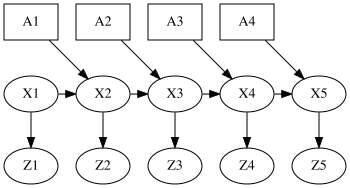

In [7]:
#| caption: A dynamic Bayes net modeling both actions and sensing.
#| label: fig:dbn_5
dbn = gtsam.DiscreteBayesNet()
for k in range(1,N+1):
    dbn.add(Z[k], [X[k]], vacuum.sensor_spec) # Add measurement CPTs
for k in reversed(range(1, N)):
    dbn.add(X[k+1], [X[k], A[k]], vacuum.action_spec) # Add transition CPTs
dbn.add(X[1], "0/0/1/0/0") # Add initial state CPT

show(dbn, hints={"A":2, "X":1, "Z":0}, boxes={A[k][0] for k in range(1,N)})

Observe that after the first time step, the Bayes net is repeating the same "AXZ" pattern (or *slice*!) over and over again. Formally, the joint distribution $P(Z_{1:n},X_{1:n}|A_{1:n})$ over states $X_{1:n} \doteq (X_1 \dots, X_n)$ and measurements $Z_{1:n} \doteq (Z_1, \dots , Z_n)$, *given*
the action sequence $A_{1:n} \doteq (A_1, \dots , A_n)$ can be computed, given the DBN factorization, as
\begin{equation}
P(Z_{1:n},X_{1:n}|A_{1:n})= P(Z_1| X_1) P(X_1) \prod_{k=2}^{n} P(Z_k| X_k) P(X_k|A_{k-1},X_{k-1}).
\end{equation}
The AXZ slice at time $k$ is given by $P(Z_k| X_k) P(X_k|A_{k-1},X_{k-1})$, whereas the chain is "jump-started" using the initial state distribution $P(X_1)$ and the corresponding measurement model $P(Z_1|X_1)$.

## Ancestral Sampling

> FOR DBNs, ancestry matters!

How do we sample over such a complex Bayes net? To explain, recall the Bayes net example from Figure [11](#fig:general_bayes_net) in the previous section. It has four variables W,X,Y,Z, and the joint distribution
\begin{equation}
P(W,X,Y,Z)=P(W|X,Z)P(X|Y,Z)P(Y|Z)P(Z).
\end{equation}

```{index} topological sort
```
Sampling from the joint distribution given in Bayes net form can be done
by sampling each variable in turn, but making sure that we always sample
a node’s parents first. This can be done using the notion of a
**topological sort** of the DAG. A topological sort of a DAG is an ordering
of the vertices $\{v_1, \dots , v_n\}$ such that $v_i$ precedes $v_j$ in the sort when there
is a directed edge from $v_i$ to $v_j$ in the DAG.

```{index} Kahn’s algorithm
```
An easy algorithm to obtain a topological sort is **Kahn’s algorithm**,
which iteratively removes nodes from the graph that either have no parents, or whose parents have all been removed already.
The order in which nodes are removed constitutes a (non-unique) topological sort order.

Sampling is then done by sampling from each variable separately, in topological sort order, as doing so will ensure each variable's parent values are already available.
The example graph above happens to be laid out already in topological sort order, if read from top to bottom.
Hence, in this example we sample first $Z$, then $Y$, then $X$, and then $W$.
Note that in this case the topological sort happens to be unique, but that is an exception rather than the rule: for arbitrary Bayes nets, more than one topological sort can exist.

## Simulation of a Robot

> Simulation as sampling, once again!

Simulation of a robot is then equivalent
to ancestral sampling from the DBN associated with the robot, i.e., the controlled Markov chain augmented with the measurement CPTs.
In this case one topological sort is
rather obvious, and so is a simulation algorithm to sample from
$P(X_{1:n},Z_{1:n}|A_{1:n})$:

1. First, assign $k\leftarrow1$, and sample the initial state $x_1$ from $P(X_1)$, a prior over the state. We write
$$
x_1 \sim P(X_1)
$$

2. Next, simulate the sensor reading by sampling from the sensor model
$$
z_{k} \sim P(Z_{k}|X_{k}=x_{k})
$$

3. Lastly, simulate the effect of the (given) action $a_k$ by sampling the next state $x_{k+1}$:
$$
x_{k+1} \sim P(X_{k+1}|X_{k}=s_{k},A_{k}=a_{k}).
$$

4. Increase $k\leftarrow k+1$ and return to step $2$.

Note that this algorithm is generic for all robot models with this action/sensing structure.

### Exercises

1. Simulate two different realizations from the dynamic Bayes net above.

1. Think of a different way to topologically sort the graph, and the corresponding sampling algorithm.

## Ancestral Sampling with GTSAM

> Simulation in code.

Of course, GTSAM has a method built in to do ancestral sampling, *but* it only works for a *reverse* topologically sorted Bayes net. This matches the way we write down joint distributions, with parents towards the right, and it is also why above we used the built-in `reversed` on the range: this was to make sure that later states get sampled last. Because in our code above we only specified
$P(Z_{1:n},X_{1:n}|A_{1:n})$, and specifically did not provide a distribution over actions, we need to give an action sequence $a_{1:n}$ as an argument.

In [8]:
#| caption: Sampling from the DBN.
#| label: fig:dbn-sample
actions = VARIABLES.assignment({A[k]: "R" for k in range(1,N)})
pretty(dbn.sample(actions))


Variable,value
A1,R
A2,R
A3,R
A4,R
X1,Office
X2,Office
X3,Hallway
X4,Dining Room
X5,Dining Room
Z1,dark


As an example, in Figure [3](#fig:dbn-sample) we examine what happens when we try the action `Right` 4 times in a row. The actions are included in the resulting `DiscreteValues` instance, so we have a complete picture of one sampled "world state" over time.
Note that the result now also includes the sampled measurements $Z_k$ at each time step, in addition to the states $X_k$.
Not surprisingly, we quickly transition from the dark hallway to the slightly brighter dining room and get stuck there, as there is no room to the right of the dining room!

### Exercises

- Execute the cell above multiple times and observe you *do* get different realizations (almost) every time.
- Try doing the same with different action sequences.
- Try formulating an action sequence that gets you to the kitchen. Does it always succeed?

## GTSAM 101
> The GTSAM concepts used in this section, explained.

We use the `DiscreteBayesNet` method `sample`, with signature

```python
    sample(self, given: gtsam::DiscreteValues) -> gtsam::DiscreteValues
```

It implements ancestral sampling, but does assume that the Bayes net is reverse topologically sorted, i.e. last
conditional will be sampled first. In addition, it can optionally take an assignment for certain *given* variables, as a `DiscreteValues` instance.
In that case, it is also assumed that the Bayes net does not contain any conditionals for the given values.
We used this functionality to pass the given action sequence above.